# Validación de actividad humana

Este notebook construye o reutiliza la capa estática basada en OpenStreetMap, valida sus tres variables y las representa sobre Galicia. La descarga solo ocurre si no existe el extracto Shapefile versionado en `data/raw/human_activity/`.

Variables: `distance_to_road_m`, `road_length_km` y `distance_to_residential_area_m`. No son variables diarias: se calculan una vez por celda de 1 km.

In [1]:
import sys
from pathlib import Path

# Permite ejecutarlo desde PyCharm (raíz) y desde Jupyter (notebooks/).
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from src.config import (
    GRID_PATH,
    HUMAN_ACTIVITY_CUBE_PATH,
    HUMAN_ACTIVITY_RAW_DIR,
    SPATIAL_CUBE_PATH,
)
from src.geospatial.human_activity import (
    OSM_GALICIA_2022_URL,
    construir_capa_actividad_humana,
)

print(f'Fuente fija: {OSM_GALICIA_2022_URL}')
print(f'Archivo local: {HUMAN_ACTIVITY_RAW_DIR}')

Fuente fija: https://download.geofabrik.de/europe/spain/galicia-220101-free.shp.zip
Archivo local: C:\Users\alfon\PycharmProjects\Sistema-deteccion-incendios\data\raw\human_activity


In [2]:
# Descarga el extracto OSM solo si falta y genera la capa estática.
construir_capa_actividad_humana(
    grid_path=GRID_PATH,
    spatial_cube_path=SPATIAL_CUBE_PATH,
    output_path=HUMAN_ACTIVITY_CUBE_PATH,
    raw_dir=HUMAN_ACTIVITY_RAW_DIR,
)
print(f'✓ Capa creada: {HUMAN_ACTIVITY_CUBE_PATH}')

✓ Capa creada: C:\Users\alfon\PycharmProjects\Sistema-deteccion-incendios\data\processed\static\human_activity_1km.nc


In [3]:
with xr.open_dataset(SPATIAL_CUBE_PATH) as spatial, xr.open_dataset(HUMAN_ACTIVITY_CUBE_PATH) as human:
    active = spatial['is_galicia'].astype(bool)
    print(human)
    for variable in human.data_vars:
        values = human[variable].where(active)
        print(
            f'{variable}: min={float(values.min()):.2f}, '
            f'mediana={float(values.median()):.2f}, max={float(values.max()):.2f}'
        )
    assert set(human.data_vars) == {
        'distance_to_road_m',
        'road_length_km',
        'distance_to_residential_area_m',
    }
    # Fuera de Galicia se conserva NaN deliberadamente; solo validamos la máscara activa.
    for variable in human.data_vars:
        values = human[variable]
        assert int((values.isnull() & active).sum()) == 0
        assert (values.values[active.values] >= 0).all()
print('✓ Esquema, cobertura y rangos válidos.')

<xarray.Dataset> Size: 552kB
Dimensions:                         (y: 225, x: 203)
Coordinates:
  * y                               (y) int64 2kB 2245000 2246000 ... 2469000
  * x                               (x) int64 2kB 2760000 2761000 ... 2962000
Data variables:
    distance_to_road_m              (y, x) float32 183kB ...
    road_length_km                  (y, x) float32 183kB ...
    distance_to_residential_area_m  (y, x) float32 183kB ...
Attributes:
    title:    Human activity variables
    source:   OpenStreetMap via Geofabrik, Galicia snapshot 2022-01-01
    module:   human_activity
    crs:      EPSG:3035
distance_to_road_m: min=0.00, mediana=0.00, max=7722.79
road_length_km: min=0.00, mediana=2.01, max=33.55
distance_to_residential_area_m: min=0.00, mediana=0.00, max=8007.90
✓ Esquema, cobertura y rangos válidos.


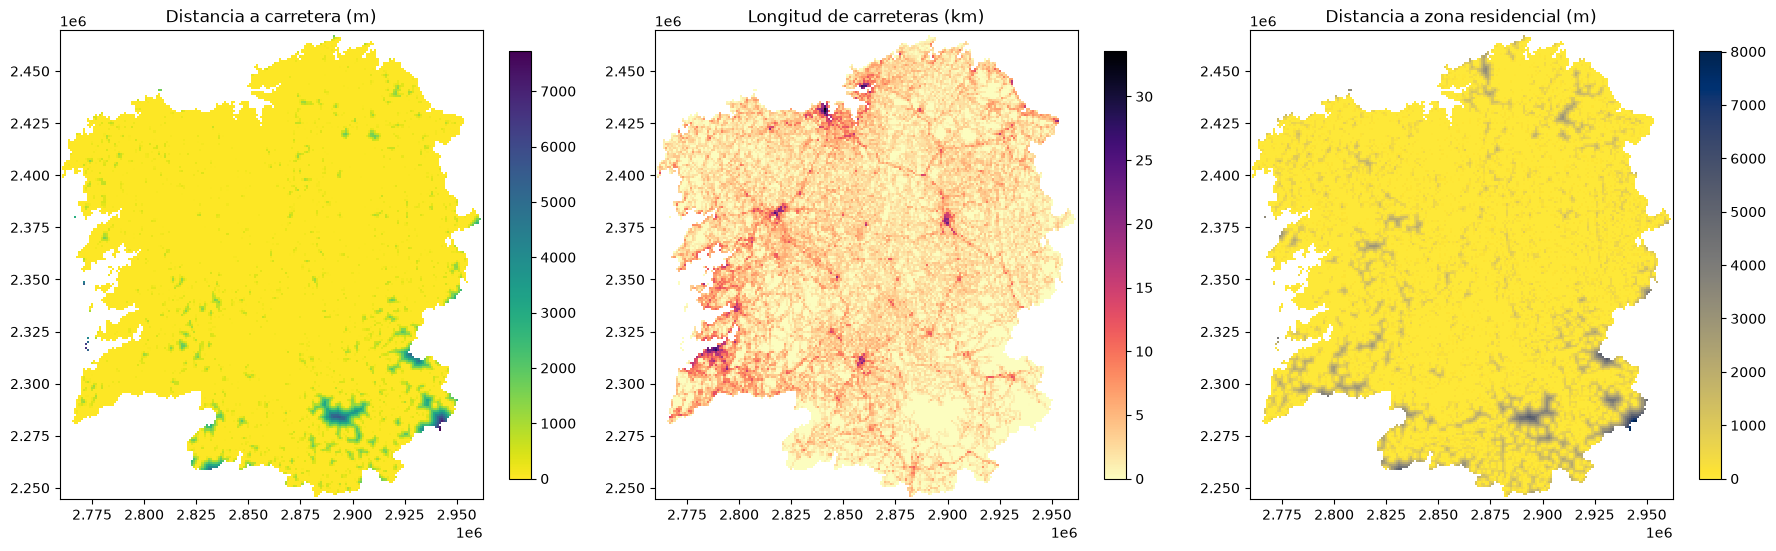

In [4]:
with xr.open_dataset(SPATIAL_CUBE_PATH) as spatial, xr.open_dataset(HUMAN_ACTIVITY_CUBE_PATH) as human:
    active = spatial['is_galicia'].astype(bool)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
    plots = [
        ('distance_to_road_m', 'Distancia a carretera (m)', 'viridis_r'),
        ('road_length_km', 'Longitud de carreteras (km)', 'magma_r'),
        ('distance_to_residential_area_m', 'Distancia a zona residencial (m)', 'cividis_r'),
    ]
    for ax, (variable, title, cmap) in zip(axes, plots, strict=True):
        image = human[variable].where(active).plot(ax=ax, cmap=cmap, add_colorbar=False)
        fig.colorbar(image, ax=ax, shrink=.75)
        ax.set(title=title, xlabel='', ylabel='', facecolor='white')
        ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

## Integración final

Al ejecutar `python -m src.workflow`, la capa se crea automáticamente si falta. Para recalcularla con el mismo extracto OSM local, usar `--rebuild-human-activity`. Después, el NetCDF final y los Parquet incluyen las tres variables como predictores estáticos.